In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (train_test_split, GridSearchCV,
                                      RandomizedSearchCV, cross_val_score)
from sklearn.metrics import accuracy_score, classification_report

cancer = load_breast_cancer()
X = pd.DataFrame(cancer.data, columns=cancer.feature_names)
y = cancer.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Data loaded!")
print("Train size:", X_train.shape)

Data loaded!
Train size: (455, 30)


In [2]:
base_model = RandomForestClassifier(random_state=42)
base_model.fit(X_train, y_train)
base_pred = base_model.predict(X_test)
base_acc = accuracy_score(y_test, base_pred)

print(f"Baseline Accuracy: {base_acc*100:.2f}%")

Baseline Accuracy: 96.49%


In [3]:
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

print("GridSearch Best Params:", grid_search.best_params_)
print(f"GridSearch Best Score: {grid_search.best_score_*100:.2f}%")

GridSearch Best Params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
GridSearch Best Score: 96.26%


In [4]:
from scipy.stats import randint

param_dist = {
    "n_estimators": randint(50, 300),
    "max_depth": [None, 5, 10, 15, 20],
    "min_samples_split": randint(2, 10)
}

random_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_dist,
    n_iter=20,
    cv=5,
    scoring="accuracy",
    random_state=42,
    n_jobs=-1
)
random_search.fit(X_train, y_train)

print("RandomSearch Best Params:", random_search.best_params_)
print(f"RandomSearch Best Score: {random_search.best_score_*100:.2f}%")

RandomSearch Best Params: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 253}
RandomSearch Best Score: 96.04%


In [5]:
best_model = grid_search.best_estimator_
best_pred = best_model.predict(X_test)
best_acc = accuracy_score(y_test, best_pred)

print(f"Optimized Model Accuracy: {best_acc*100:.2f}%")
print(classification_report(y_test, best_pred))

Optimized Model Accuracy: 96.49%
              precision    recall  f1-score   support

           0       0.98      0.93      0.95        43
           1       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



In [6]:
cv_scores = cross_val_score(best_model, X, y, cv=10, scoring="accuracy")

print(f"Cross-Validation Scores: {cv_scores.round(3)}")
print(f"Mean CV Accuracy: {cv_scores.mean()*100:.2f}%")
print(f"Std Deviation: {cv_scores.std()*100:.2f}%")

Cross-Validation Scores: [0.982 0.895 0.947 0.965 1.    0.982 0.947 0.982 0.947 0.982]
Mean CV Accuracy: 96.31%
Std Deviation: 2.88%


                Model  Accuracy
0            Baseline     96.49
1        GridSearchCV     96.26
2  RandomizedSearchCV     96.04


C:\Users\HP15\AppData\Local\Temp\ipykernel_9420\3269438886.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=report, x="Model", y="Accuracy", palette="Set2")


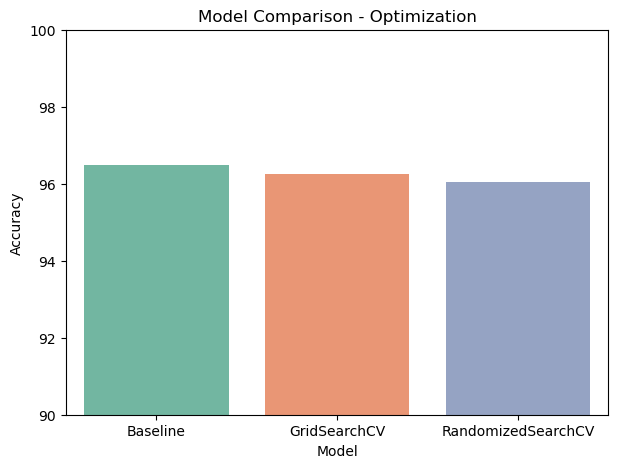

In [7]:
report = pd.DataFrame({
    "Model": ["Baseline", "GridSearchCV", "RandomizedSearchCV"],
    "Accuracy": [
        base_acc,
        grid_search.best_score_,
        random_search.best_score_
    ]
})
report["Accuracy"] = (report["Accuracy"] * 100).round(2)
report.to_csv("best_parameters_report.csv", index=False)
print(report)

plt.figure(figsize=(7, 5))
import seaborn as sns
sns.barplot(data=report, x="Model", y="Accuracy", palette="Set2")
plt.title("Model Comparison - Optimization")
plt.ylim(90, 100)
plt.savefig("optimization_comparison.png")
plt.show()